In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,
    downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/ld3228/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


### 1) Opening data and examining metadata

In [3]:
# 1.1) Open the dataset and display its contents
ds = xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 737MB
Dimensions:                      (time: 203, lat: 180, lon: 360)
Coordinates:
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [4]:
# 1.2) Print out the long_name attribute of each variable
for var in ds.data_vars:
    print(f"{var:<40} {ds[var].attrs['long_name']}")

toa_sw_all_mon                           Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon                           Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon                          Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon                           Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon                           Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon                          Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon                           Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon                           Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon                          Top of The Atmosphere Cloud Radiative Effects Net Flux, 

In [5]:
ds_mean = ds.mean(dim='time')
ds_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lat: 180, lon: 360)
Coordinates:
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

### 2) Basic reductions, arithmetic, and plotting

In [6]:
ds_mean['toa_lw_all_sky'].plot()
plt.title('Time-Mean TOA Longwave Radiation (All-Sky)')
plt.show()

KeyError: "No variable named 'toa_lw_all_sky'. Did you mean one of ('toa_lw_all_mon', 'toa_sw_all_mon', 'toa_lw_clr_mon', 'toa_net_all_mon')?"

In [ ]:
print(list(ds_mean.data_vars))

In [ ]:
ds_mean['toa_lw_all_mon'].plot()
plt.title('Time-Mean TOA Longwave Radiation (All-Sky)')
plt.show()

In [ ]:
# 2.1) Calculate the time-mean of the entire dataset
ds_mean['toa_sw_all_mon'].plot()
plt.title('Time-Mean TOA Shortwave Radiation (All-Sky)')
plt.show()

In [ ]:
# 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation
ds_mean['solar_mon'].plot()
plt.title('Time-Mean TOA Incoming Solar Radiation')
plt.show()

In [ ]:
# 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux
toa_net_computed = ds_mean['solar_mon'] - ds_mean['toa_sw_all_mon'] - ds_mean['toa_lw_all_mon']
toa_net_computed.plot()
plt.title('Computed TOA Net Flux')
plt.show()

In [ ]:
ds_mean['toa_net_all_mon'].plot()
plt.title('Actual TOA Net Flux (All-Sky)')
plt.show()

### 3) Mean and weighted mean

In [ ]:
# 3.1) Calculate the global (unweighted) mean of TOA net radiation
unweighted_mean = ds_mean['toa_net_all_mon'].mean()
print(f"Unweighted global mean: {unweighted_mean.values:.4f} W/m²")

In [ ]:
# 3.2) Create a weight array proportional to cos
weights = np.cos(np.deg2rad(ds_mean.lat))
weights

In [ ]:
# 3.3) Redo your global mean TOA net radiation calculation with this weight factor
weighted_mean = ds_mean['toa_net_all_mon'].weighted(weights).mean(('lat', 'lon'))
print(f"Weighted global mean: {weighted_mean.values:.4f} W/m²")

In [ ]:
# 3.4) Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment
for var in ['solar_mon', 'toa_lw_all_mon', 'toa_sw_all_mon']:
    val = ds_mean[var].weighted(weights).mean(('lat', 'lon'))
    print(f"{var:<30} {val.values:.2f} W/m²")

### 4) Meridional Heat Transport Calculation

In [ ]:
# 4.1) calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it
R = 6.371e6  # Earth's radius in meters
dlat = np.deg2rad(1.0)
dlon = np.deg2rad(1.0)

area = R**2 * np.cos(np.deg2rad(ds_mean.lat)) * dlat * dlon
area_2d = xr.ones_like(ds_mean['toa_net_all_mon']) * area

# Verify against true surface area of Earth
print(f"Sum of pixel areas:  {float(area_2d.sum()):.4e} m²")
print(f"True Earth surface:  {4 * np.pi * R**2:.4e} m²")

In [ ]:
# 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band
total_rad = (ds_mean['toa_net_all_mon'] * area_2d).sum(dim='lon')
total_rad.plot()
plt.title('Total Net Radiation per Latitude Band')
plt.ylabel('W')
plt.show()

In [ ]:
# 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude
heat_transport = total_rad.cumsum(dim='lat')
heat_transport.plot()
plt.title('Cumulative TOA Net Radiation (Meridional Heat Transport)')
plt.ylabel('W')
plt.xlabel('Latitude')
plt.axhline(0, color='k', linestyle='--')
plt.show()

### 5) Making Maps with Cartopy

In [ ]:
import sys
!{sys.executable} -m pip install cartopy

In [ ]:
import sys
!{sys.executable} -m pip install netcdf4

In [ ]:
import sys
!{sys.executable} -m pip install "numpy<2"

/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'apcp' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/ld3228/.local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ld3228/.local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ld3228/.local

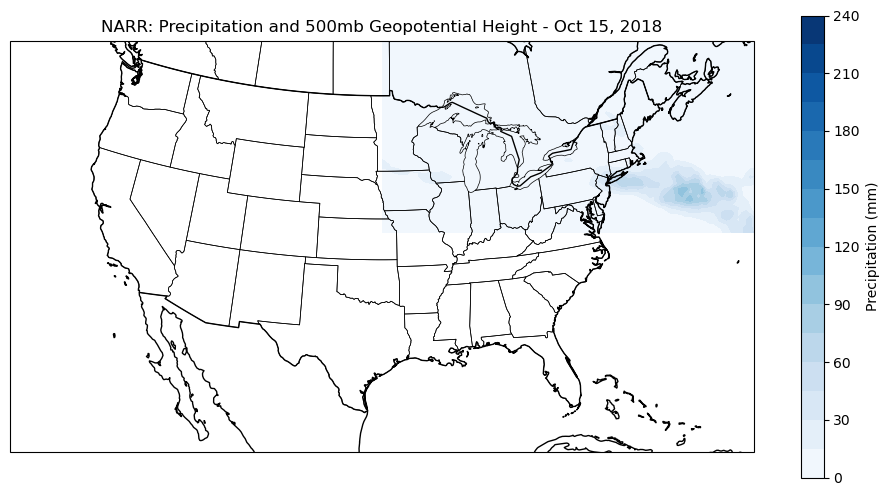

In [7]:
# 5.1) Plot data from NARR
import cartopy.crs as ccrs
import cartopy.feature as cfeature

url_hgt = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/pressure/hgt.201810.nc"
url_apcp = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/monolevel/apcp.2018.nc"

ds_hgt = xr.open_dataset(url_hgt, engine="netcdf4")
ds_apcp = xr.open_dataset(url_apcp, engine="netcdf4")

# Select Oct 15 2018 and 500mb level
hgt_500 = ds_hgt['hgt'].sel(level=500, time='2018-10-15', method='nearest')
precip = ds_apcp['apcp'].sel(time='2018-10-15', method='nearest')

# Plot
proj = ccrs.LambertConformal()
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(12, 6))
ax.set_extent([-125, -67, 23, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.5)

cf = ax.contourf(precip.x, precip.y, precip.values, cmap='Blues', levels=20, transform=proj)
cs = ax.contour(hgt_500.x, hgt_500.y, hgt_500.values, colors='black', levels=15, transform=proj)
ax.clabel(cs, fmt='%d')
plt.colorbar(cf, ax=ax, label='Precipitation (mm)')
plt.title('NARR: Precipitation and 500mb Geopotential Height - Oct 15, 2018')
plt.show()

/home/ld3228/.local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


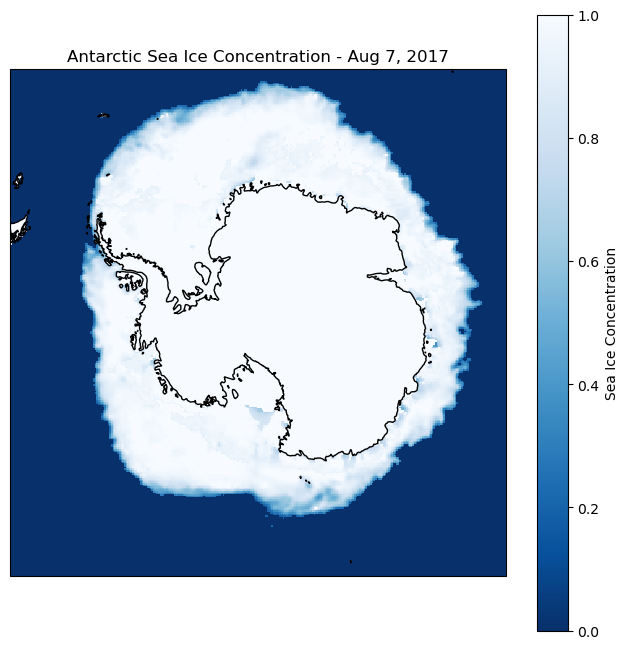

In [8]:
# 5.2) Antarctic Sea Ice
url_ice = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname_ice = pooch.retrieve(url_ice, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname_ice, drop_variables='melt_onset_day_seaice_conc_cdr')

ice = ds_ice['seaice_conc_cdr'].isel(time=0)

proj_ice = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(subplot_kw={'projection': proj_ice}, figsize=(8, 8))
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)

cf = ax.pcolormesh(ds_ice.longitude, ds_ice.latitude, ice.values,
                   cmap='Blues_r', transform=ccrs.PlateCarree(), vmin=0, vmax=1)
plt.colorbar(cf, ax=ax, label='Sea Ice Concentration')
plt.title('Antarctic Sea Ice Concentration - Aug 7, 2017')
plt.show()

/home/ld3228/.local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ld3228/.local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ld3228/.local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


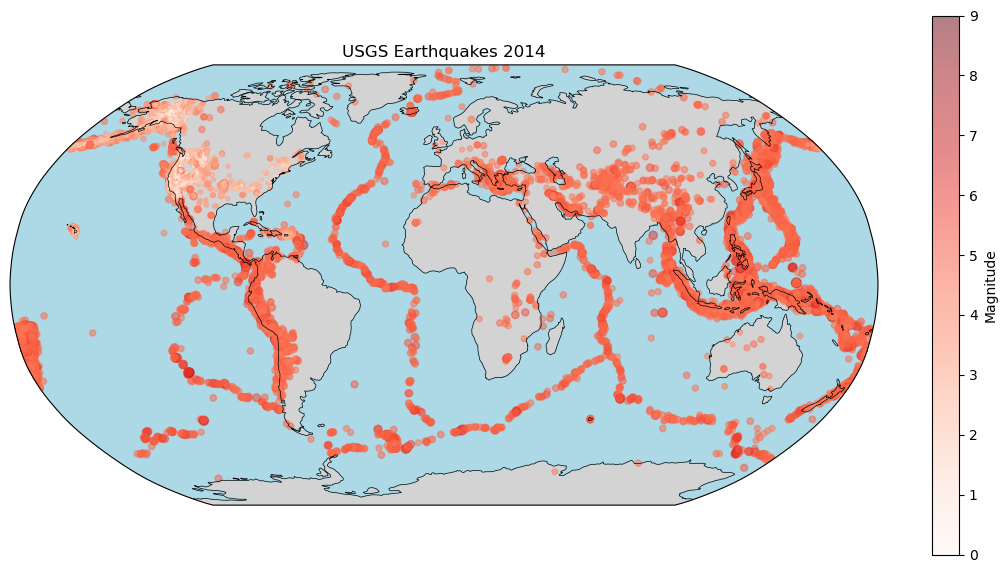

In [9]:
# 5.3) Global USGS Earthquakes
import pandas as pd

df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv')

proj_eq = ccrs.Robinson()
fig, ax = plt.subplots(subplot_kw={'projection': proj_eq}, figsize=(14, 7))
ax.set_global()
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

sc = ax.scatter(df['longitude'], df['latitude'],
                c=df['mag'], cmap='Reds',
                s=df['mag']**2, alpha=0.5,
                transform=ccrs.PlateCarree(), vmin=0, vmax=9)
plt.colorbar(sc, ax=ax, label='Magnitude')
plt.title('USGS Earthquakes 2014')
plt.show()